<a href="https://colab.research.google.com/github/mipaillafil/telco-ml-e1/blob/main/telco_modelamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telco Customer Churn — Modelamiento y Evaluación**

Se comparan tres algoritmos de clasificación:
1. Regresión Logística
2. Random Forest
3. Gradient Boosting


##**Criterio de Salida Inicial**
Para terminar el proceso de prueba y error se establecen inicialmente:

- **Recall >= 0,75**
- **F1-score >= 0,60**
- **ROC-AUC >= 0,80**

El Recall se prioriza porque interesa detectar la mayor cantidad posible de clientes que realmente abandonan.


##**Importar Librerias**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



##**Cargar Datos de Entrenamiento y Prueba**

In [2]:
X_train = pd.read_csv("https://raw.githubusercontent.com/mipaillafil/telco-ml-e1/main/data/processed/X_train.csv")
X_test = pd.read_csv("https://raw.githubusercontent.com/mipaillafil/telco-ml-e1/main/data/processed/X_test.csv")
y_train = pd.read_csv("https://raw.githubusercontent.com/mipaillafil/telco-ml-e1/main/data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("https://raw.githubusercontent.com/mipaillafil/telco-ml-e1/main/data/processed/y_test.csv").squeeze("columns")

print("Datos cargados:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Datos cargados:
X_train: (5634, 30)
X_test: (1409, 30)


##**Modelo 1: Regresión Logística**

In [3]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    y_pred_log,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



##**Modelo 2: Random Forest**

In [4]:
rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



##**Modelo 3: Gradient Boosting**

In [5]:
gb_clf = GradientBoostingClassifier(
    random_state=42
)

gb_clf.fit(X_train, y_train)

y_pred_gb = gb_clf.predict(X_test)
y_prob_gb = gb_clf.predict_proba(X_test)[:, 1]

print(classification_report(
    y_test,
    y_pred_gb,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1035
       Churn       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



##**Comparación de Métricas**

In [6]:
modelos = {
    "Regresión Logística": (y_pred_log, y_prob_log),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "Gradient Boosting": (y_pred_gb, y_prob_gb)
}

resultados = []

for nombre, (pred, prob) in modelos.items():
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

resultados_df = pd.DataFrame(resultados)

display(resultados_df.round(3))

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regresión Logística,0.738,0.504,0.783,0.614,0.842
1,Random Forest,0.790,0.634,0.492,0.554,0.822
2,Gradient Boosting,0.798,0.654,0.505,0.570,0.842


<Figure size 1000x600 with 0 Axes>

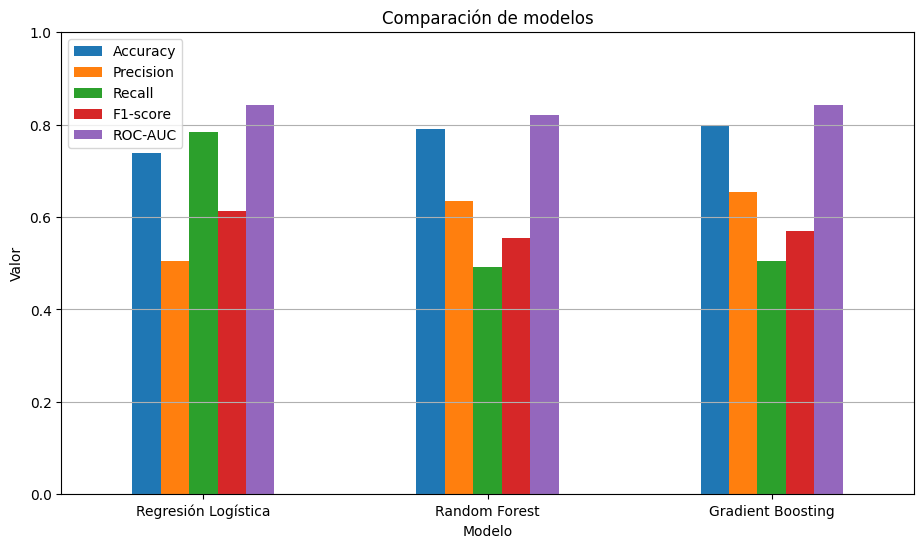

In [7]:
plt.figure(figsize=(10,6))

resultados_df.set_index("Modelo")[
    ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
].plot(kind="bar", figsize=(11,6))

plt.title("Comparación de modelos")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

##**Evaluación del Criterio de Salida**

In [8]:
umbral_recall = 0.75
umbral_f1 = 0.60
umbral_auc = 0.80

resultados_df["Cumple_Recall"] = resultados_df["Recall"] >= umbral_recall
resultados_df["Cumple_F1"] = resultados_df["F1-score"] >= umbral_f1
resultados_df["Cumple_ROC-AUC"] = resultados_df["ROC-AUC"] >= umbral_auc

resultados_df["Cumple_Criterio_Salida"] = (
    resultados_df["Cumple_Recall"] &
    resultados_df["Cumple_F1"] &
    resultados_df["Cumple_ROC-AUC"]
)

display(resultados_df.round(3))

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,Cumple_Recall,Cumple_F1,Cumple_ROC-AUC,Cumple_Criterio_Salida
0,Regresión Logística,0.738,0.504,0.783,0.614,0.842,True,True,True,True
1,Random Forest,0.790,0.634,0.492,0.554,0.822,False,False,True,False
2,Gradient Boosting,0.798,0.654,0.505,0.570,0.842,False,False,True,False


In [9]:
print("=== CRITERIO DE SALIDA ===")
print(f"Recall >= {umbral_recall:.2f}")
print(f"F1-score >= {umbral_f1:.2f}")
print(f"ROC-AUC >= {umbral_auc:.2f}")

modelos_validos = resultados_df[
    resultados_df["Cumple_Criterio_Salida"]
]

if len(modelos_validos) > 0:
    print("\nSe encontraron modelos que cumplen el criterio de salida.")
    display(modelos_validos.round(3))
else:
    print("\nNingún modelo cumple el criterio de salida.")
    print("El proceso de prueba y error debería continuar.")

=== CRITERIO DE SALIDA ===
Recall >= 0.75
F1-score >= 0.60
ROC-AUC >= 0.80

Se encontraron modelos que cumplen el criterio de salida.


,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC,Cumple_Recall,Cumple_F1,Cumple_ROC-AUC,Cumple_Criterio_Salida
0,Regresión Logística,0.738,0.504,0.783,0.614,0.842,True,True,True,True


##**Selección del Modelo**
Si más de un modelo cumple el criterio, se prioriza el Recall y luego el F1-score.

In [14]:
if len(modelos_validos) > 0:
    modelo_seleccionado = modelos_validos.sort_values(
        by=["Recall", "F1-score"],
        ascending=False
    ).iloc[0]

    print("Modelo seleccionado:", modelo_seleccionado["Modelo"])
    print("Recall:", round(modelo_seleccionado["Recall"], 3))
    print("F1-score:", round(modelo_seleccionado["F1-score"], 3))
    print("ROC-AUC:", round(modelo_seleccionado["ROC-AUC"], 3))
else:
    print("No hay un modelo seleccionado porque ninguno cumple todos los umbrales.")

Modelo seleccionado: Regresión Logística
Recall: 0.783
F1-score: 0.614
ROC-AUC: 0.842


##**Matrices de Confusión**

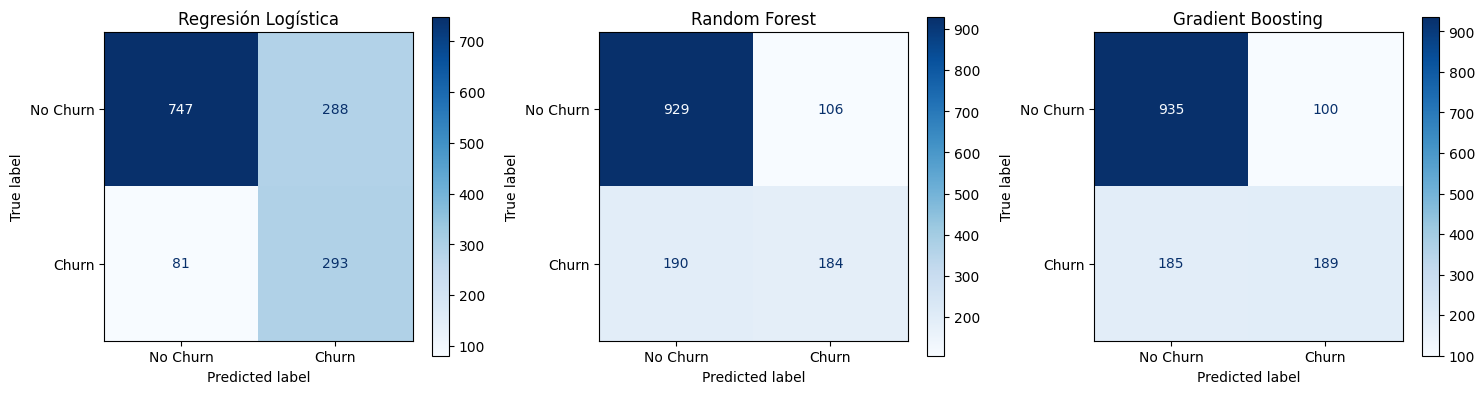

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (nombre, (pred, _)) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    ).plot(ax=ax, cmap="Blues")

    ax.set_title(nombre)

plt.tight_layout()
plt.show()

##**Variables relevantes en Regresión Logística**

Los coeficientes se revisan solamente después de entrenar el modelo.
Un coeficiente positivo aumenta la probabilidad estimada de Churn y uno negativo la reduce,
manteniendo las demás variables constantes.

In [15]:
coeficientes = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_reg.coef_[0]})

coeficientes["Impacto"] = np.where(
    coeficientes["Coeficiente"] > 0,
    "Mayor riesgo estimado",
    "Menor riesgo estimado")

print("Variables con coeficientes más positivos:")
display(
    coeficientes.sort_values(
        "Coeficiente",
        ascending=False
    ).head(10))

print("Variables con coeficientes más negativos:")
display(
    coeficientes.sort_values(
        "Coeficiente",
        ascending=True
    ).head(10))

Variables con coeficientes más positivos:


,Variable,Coeficiente,Impacto
10,InternetService_Fiber optic,1.222352,Mayor riesgo estimado
3,TotalCharges,0.486541,Mayor riesgo estimado
23,StreamingMovies_Yes,0.420611,Mayor riesgo estimado
28,PaymentMethod_Electronic check,0.402478,Mayor riesgo estimado
21,StreamingTV_Yes,0.395359,Mayor riesgo estimado
26,PaperlessBilling_Yes,0.336449,Mayor riesgo estimado
9,MultipleLines_Yes,0.324742,Mayor riesgo estimado
0,SeniorCitizen,0.153869,Mayor riesgo estimado
29,PaymentMethod_Mailed check,0.052313,Mayor riesgo estimado
17,DeviceProtection_Yes,0.041152,Mayor riesgo estimado


Variables con coeficientes más negativos:


,Variable,Coeficiente,Impacto
25,Contract_Two year,-1.412536,Menor riesgo estimado
1,tenure,-1.156175,Menor riesgo estimado
24,Contract_One year,-0.715268,Menor riesgo estimado
2,MonthlyCharges,-0.546189,Menor riesgo estimado
7,PhoneService_Yes,-0.348014,Menor riesgo estimado
13,OnlineSecurity_Yes,-0.334946,Menor riesgo estimado
19,TechSupport_Yes,-0.268557,Menor riesgo estimado
6,Dependents_Yes,-0.231225,Menor riesgo estimado
8,MultipleLines_No phone service,-0.189277,Menor riesgo estimado
14,OnlineBackup_No internet service,-0.183003,Menor riesgo estimado


##**Conclusión**

El criterio de salida permite decidir objetivamente si se debe continuar con la prueba y error.

No se selecciona necesariamente el modelo con mayor Accuracy. La decisión se basa en los
umbrales definidos antes de comparar los modelos, priorizando la detección de clientes que abandonan.
